<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [2]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &=\varphi_i + \sum_{k=1}^4 \alpha_k \times t_{i,j}^k  + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$


In [3]:
import pandas as pd

data_obs = pd.read_csv("digestibilite_py.csv", sep=";", index_col=0, decimal=",")
data_obs = data_obs.sort_values(by=["id", "sampling_days"])
data_obs

,genotype,semis,sampling,sampling_days,id,digestibilite
441,B73,date 1,1,0,1,58.659010
440,B73,date 1,2,4,1,59.003294
437,B73,date 1,3,14,1,52.008945
442,B73,date 1,4,21,1,50.589412
435,B73,date 1,5A,28,1,53.661100
...,...,...,...,...,...,...
174,NYS302,date 3,6A,35,42,57.040513
169,NYS302,date 3,7B,45,42,52.422995
180,NYS302,date 3,7A,45,42,53.256638
172,NYS302,date 3,8B,56,42,50.515760


In [4]:
mem_obs_time = jnp.array(data_obs.sampling_days).reshape((42, 8 + 4))
Y = jnp.array(data_obs.digestibilite).reshape((42, 8 + 4))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [6]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    cov_simulation,
)


class PolyMixedEffectsModel(AbstractMixedEffectsModel):
    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["phi1"],  # , "phi2"],
            **kwargs,
        )

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"PolyMEM_N{self.N}_J{self.J}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.RealPositive(shape=(1,), scale=100),
            alpha=pc.Real(shape=(4,), scale=[1, 1e-3, 1e-5, 1e-5]),
            cov_latent=pc.MatrixSymPosDef(dim=1, scale=(10)),
            var_residual=pc.RealPositive(scale=10),
        )

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)

        out = jnp.repeat(times[None, :], 4, axis=0) ** jnp.arange(1, 5)[:, None, None]

        out = (params.alpha[:, None, None] * out).sum(axis=0) + phi1[:, None]

        assert out.shape == times.shape
        return out

    # ============================================================== #
    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=3)

        time = jnp.arange(0, self.J) * 20 / self.J - 10

        time = jnp.repeat(time[None, :], self.N, axis=0)
        time = mem_obs_time

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time
        )

        return {"mem_obs_time": time} | obs, sim

### Data Generation
Then we can generate a data set with $N=2000$ individuals and $J=15$ observation time per individuals

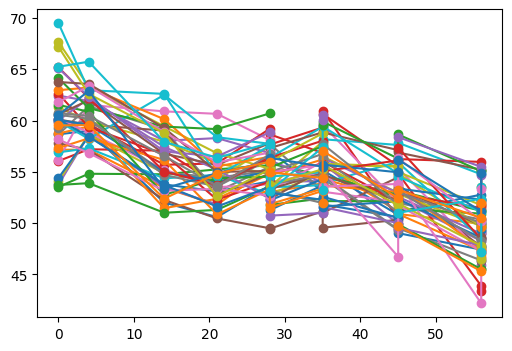

In [8]:
N, J = Y.shape
myModel = PolyMixedEffectsModel(N=N, J=J)

p_star_dict = {
    "mean_latent": jnp.array([40]),
    "alpha": jnp.array([-5.4e-01, 1.8e-02, -2.1e-04, -4.9e-17]),
    "cov_latent": jnp.diag(jnp.array([1])),
    "var_residual": jnp.array([0.0001]),
}
p_star = myModel.new_params(**p_star_dict)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure(4, 6)
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(mem_obs_time.T, Y.T, "o-")
# _ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

NameError: name 'sdgplt' is not defined

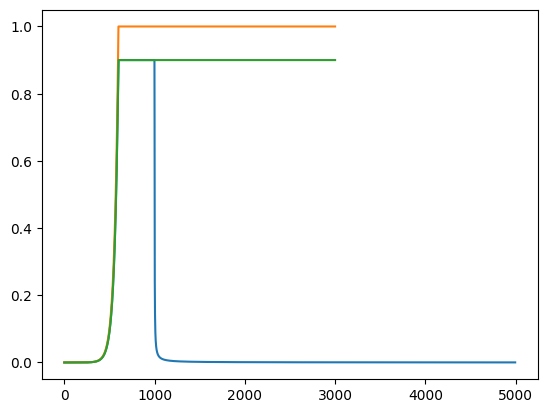

In [1]:
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.algo import SGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 1200)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [288]:
def one_estim(prngkey, model, data, lbd=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SGD_FIM(prngkey_estim, 10000, algo_settings)  # , lbd=lbd, alpha=1.0)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"phi1": 5, "phi2": 20, "phi3": 5})

    for var_lat in algo.latent_variables.values():
        var_lat.adaptative_sd = True
    # ==================== END configuration ==================== #

    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    # sdgplt.plot_mcmc(algo.latent_variables)

    return res

Now we perform severals estimations : 

In [289]:
multi_res = MultiRunRes(
    [
        one_estim(
            jrd.PRNGKey(key),
            myModel,
            data={
                "Y": Y,
                "mem_obs_time": mem_obs_time,
            },
            save_all=True,
        )
        for key in range(5)
    ]
)
if "multi_res" not in locals():
    multi_res = MultiRunRes.load(myModel)

We can obtain the calculation time

In [290]:
print(f"\nComputation time = {multi_res.chrono}")


Computation time = 0:00:07.207197


And plot the results

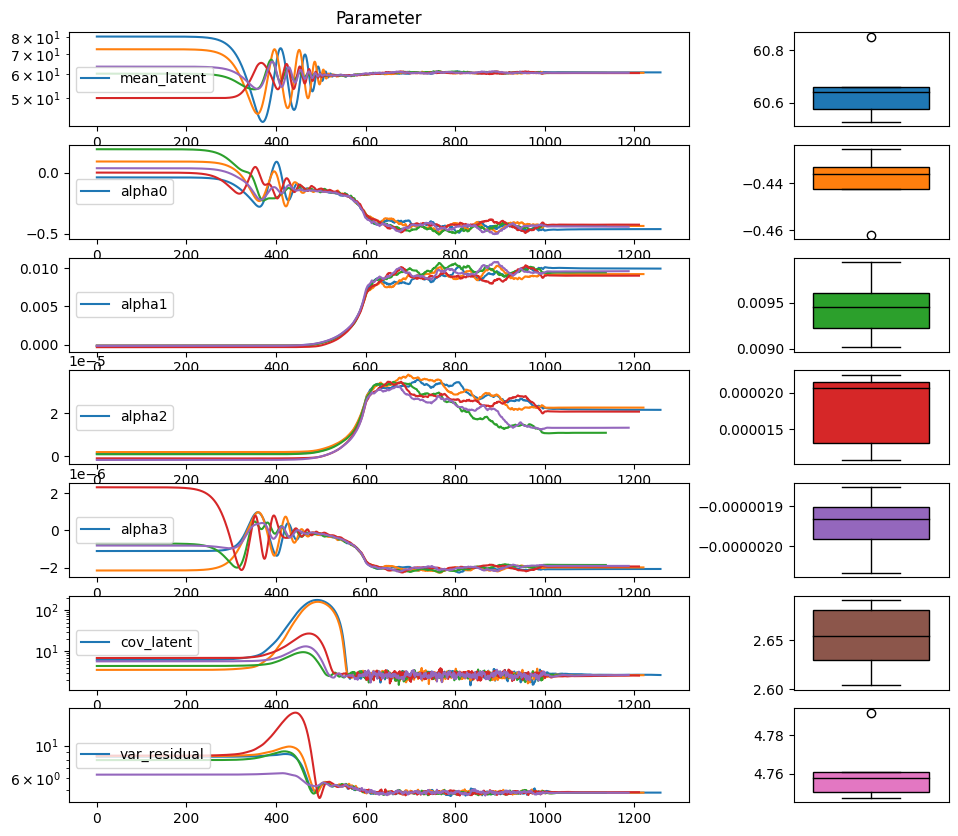

In [299]:
fig = sdgplt.figure(10, 10)
subfigs = fig.subfigures(1, 2, wspace=0.07, width_ratios=[4, 1])

_ = sdgplt.plot_theta(
    multi_res,
    params_names=myModel.params_names,
    log_scale=True,
    fig=subfigs[0],
)

f = sdgplt.boxplot_estimation(
    x=multi_res.last_theta.T,
    nrows=7,
    ncols=1,
    fig=subfigs[1],
)

for ax in f.axes:
    ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
    ax.get_yaxis().get_major_formatter().set_useOffset(False)
    ax.ticklabel_format(style="plain", axis="y")

In [301]:
p_hat = multi_res.last_theta.mean(axis=0)
params_dict = dict(
    [(key, p_hat[item]) for key, item in myModel.parametrization._idx.items()]
)
params_dict["cov_latent"] = jnp.array([params_dict["cov_latent"]])
params_dict["var_residual"] = 0
p_hat = myModel.new_params(**params_dict)
p_hat

Parameters(mean_latent=Array([60.65217992], dtype=float64), alpha=Array([-4.39847029e-01,  9.44703727e-03,  1.77106719e-05, -1.94693846e-06],      dtype=float64), cov_latent=Array([[2.65174423]], dtype=float64), var_residual=Array(0., dtype=float64))

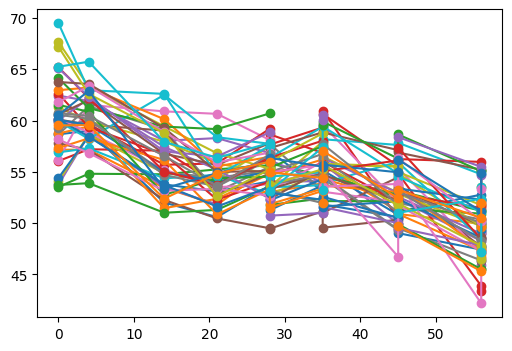

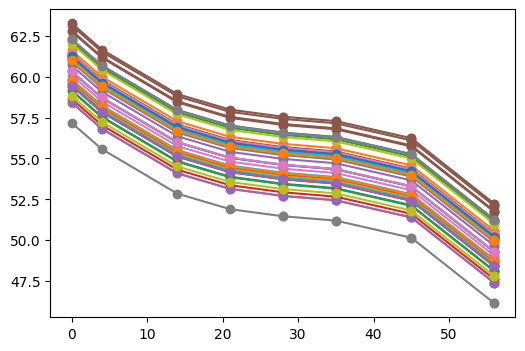

In [303]:
p_hat

myobs, mysim = myModel.sample(p_hat, jrd.PRNGKey(0))


ax = sdgplt.get_ax(4, 6)
_ = ax.plot(mem_obs_time.T, Y.T, "o-")


ax = sdgplt.get_ax(4, 6)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

In [294]:
def plot_estimation(multi_estim, id_to_plot=[0, 1, 2, 3, 6, 7]):
    fig = sdgplt.figure(8, 16)
    subfigs = fig.subfigures(1, 4, wspace=0.07, width_ratios=[4, 1, 4, 1])
    # subfigs = subfigs.reshape((subfigs.size,))

    _ = sdgplt.plot_theta(
        multi_estim,
        params_star=myModel.hstack_params(p_star),
        params_names=myModel.params_names,
        id_to_plot=id_to_plot,
        log_scale=True,
        fig=subfigs[0],
    )

    f = sdgplt.boxplot_estimation(
        # multi_estim.last_theta.T,
        x=multi_estim.last_theta.T[id_to_plot,],
        hline=myModel.hstack_params(p_star)[id_to_plot,],
        # xlabels=myModel.params_names,
        nrows=len(id_to_plot),
        ncols=1,
        fig=subfigs[1],
    )

    for ax in f.axes:
        ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
        ax.get_yaxis().get_major_formatter().set_useOffset(False)
        ax.ticklabel_format(style="plain", axis="y")

    _ = sdgplt.plot_theta_hd(
        multi_estim,
        dim_ld=myModel.DIM_LD,
        params_star=myModel.hstack_params(p_star),
        params_names=myModel.params_names,
        fig=subfigs[2],
    )

    f = sdgplt.boxplot_estimation(
        multi_estim.last_theta.T[myModel.DIM_LD :],
        hline=myModel.hstack_params(p_star)[myModel.DIM_LD :],
        # xlabels=myModel.params_names[myModel.DIM_LD :],
        nrows=myModel.P,
        ncols=1,
        fig=subfigs[3],
    )
    for ax in f.axes:
        ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
        ax.get_yaxis().get_major_formatter().set_useOffset(False)
        ax.ticklabel_format(style="plain", axis="y")

    return fig


fig = plot_estimation(multi_res)
# fig.tight_layout()

IndexError: index 7 is out of bounds for axis 0 with size 7

<Figure size 1600x800 with 0 Axes>

In [ ]:
sdgplt.get_dataframe_results(
    multi_res.last_theta, myModel.hstack_params(p_star), myModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,mean,variance,RMSE,RRMSE
mu1,1.0,0.80,0.000,0.197732,19.773242
alpha0,1.0,-0.04,0.000,1.039046,103.904608
alpha1,100.0,-0.08,0.000,100.082918,100.082918
alpha2,1.0,0.12,0.000,0.884458,88.445794
alpha3,-1.0,-0.11,0.000,0.889536,88.953578
cov_latent,1.0,0.62,0.000,0.375631,37.563082
var_residual,1.0,0.84,0.000,0.161320,16.131959


## Numerical Proof

### Sans correlation entre les effets aléatoires

On définit un modèle avec un parametrisation spécifique pour la matrice de variance-covariance pour les variables latentes, on utilisante MatrixDiagPosDef pour forcer la forme diagonale définit positive.

In [ ]:
class HDLogisticMEM_not_corr(HDLogisticMixedEffectsModel):
    def __init__(self, N=1, J=1, P=1):
        HDLogisticMixedEffectsModel.__init__(self, N=N, J=J, P=P)

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=100),
                mu2=pc.RealPositive(scale=2000),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(2000, 2000)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)


mynotCorrModel = HDLogisticMEM_not_corr(N=200, J=15, P=3)


Computation time = 0:00:54.332622


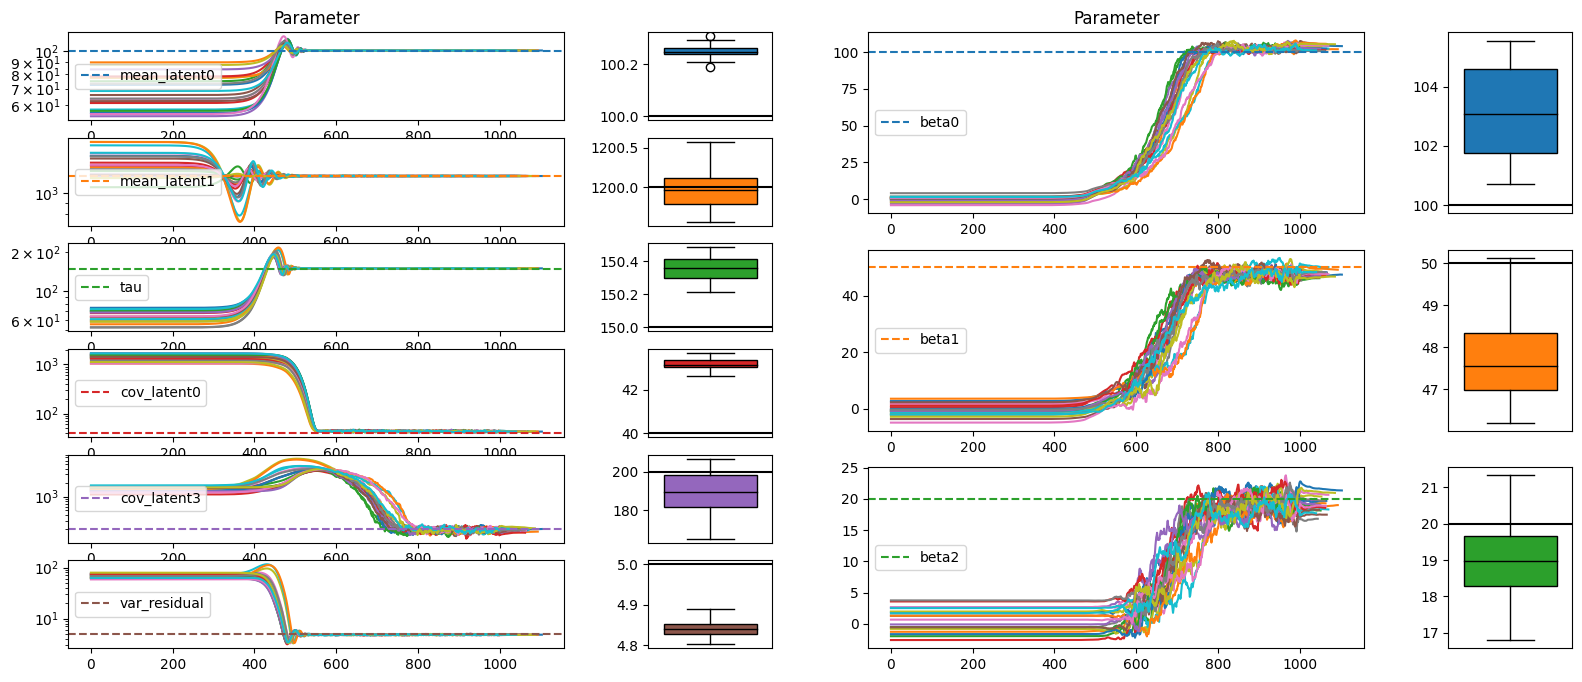

In [ ]:
p_star = mynotCorrModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([40, 200])),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate(
        [jnp.array([100, 50, 20]), jnp.zeros(shape=(mynotCorrModel.P - 3,))]
    ),
)
myobs, _ = mynotCorrModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [
        one_estim(jrd.PRNGKey(key), mynotCorrModel, myobs, save_all=True)
        for key in range(20)
    ]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res)


Computation time = 0:00:20.657132


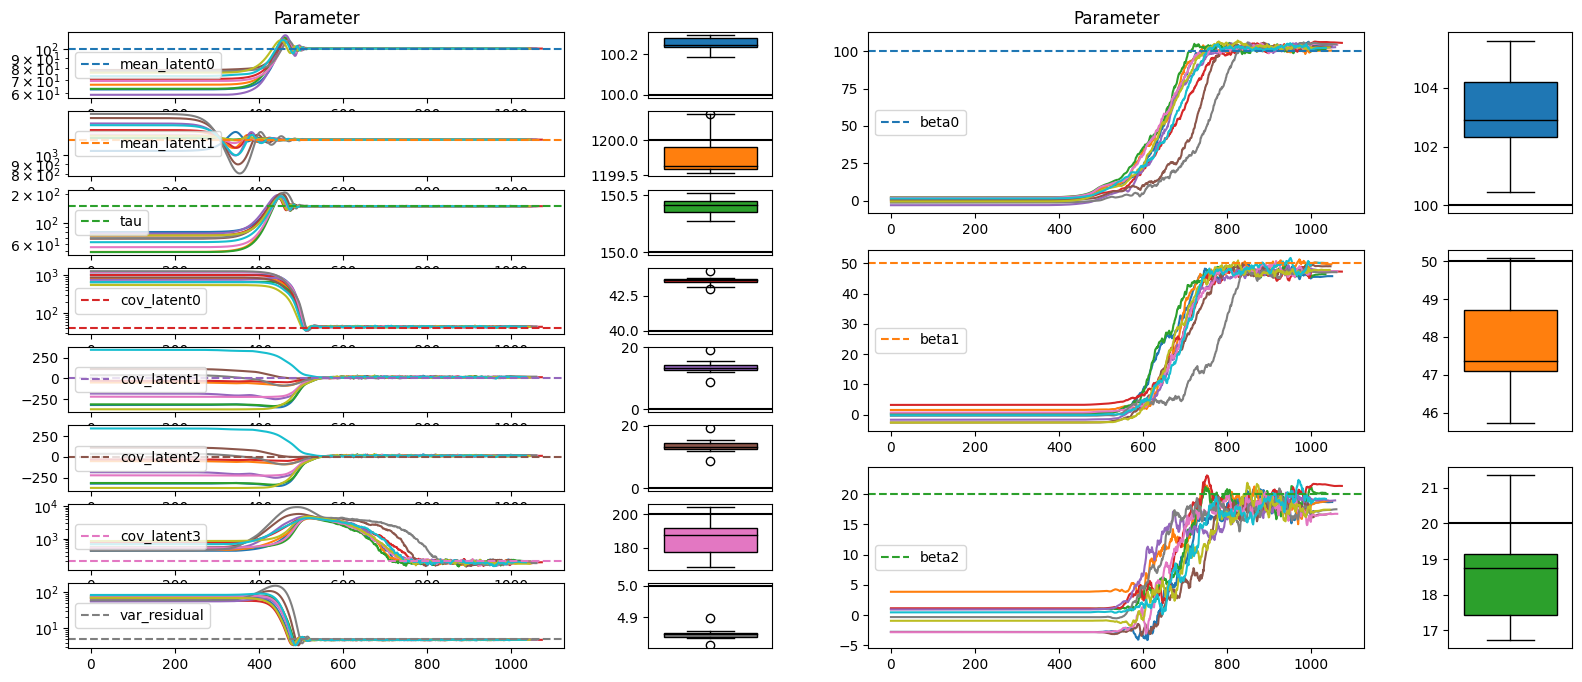

In [ ]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 0], [0, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

### Sans correlation entre les effets aléatoires

#### Correlation faible


Computation time = 0:00:24.410329


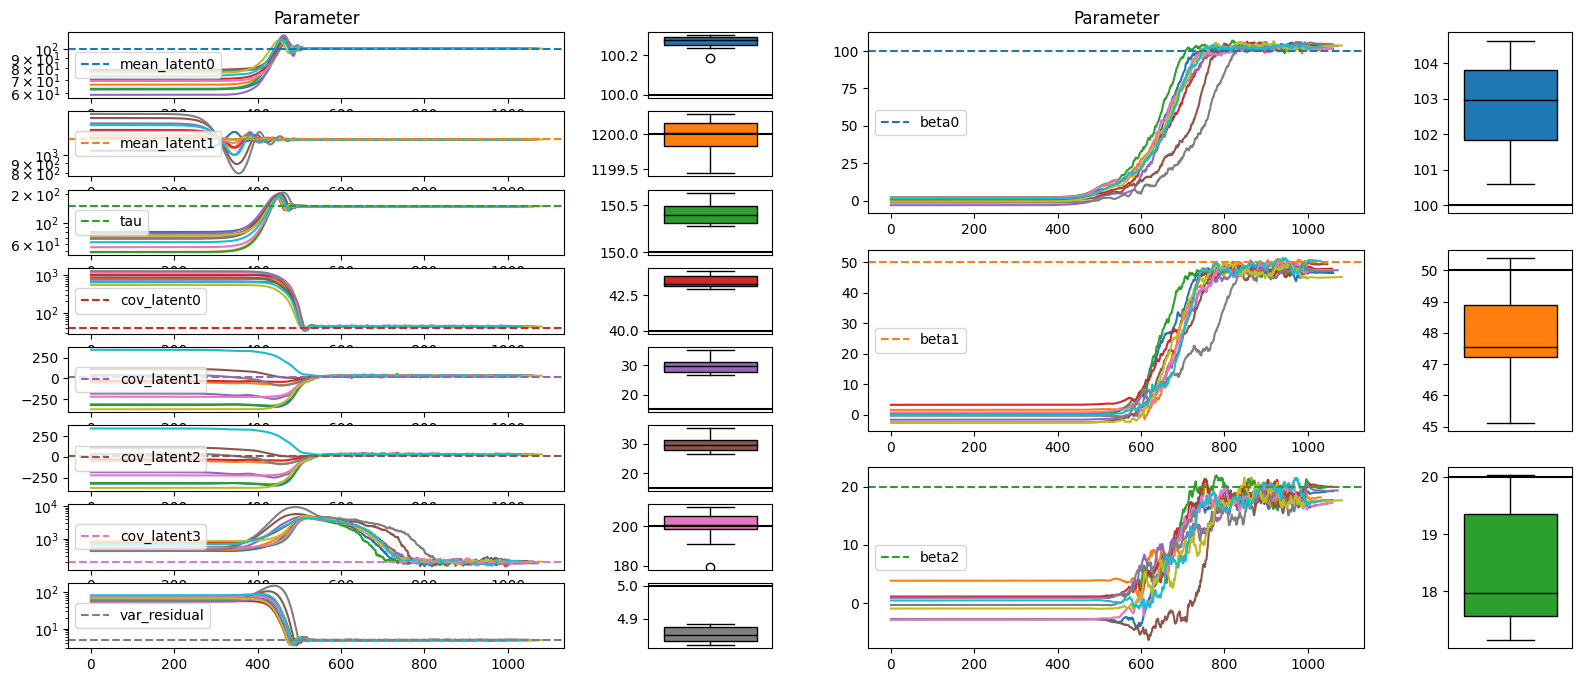

In [ ]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 15], [15, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

#### Correlation moyen


Computation time = 0:00:25.058565


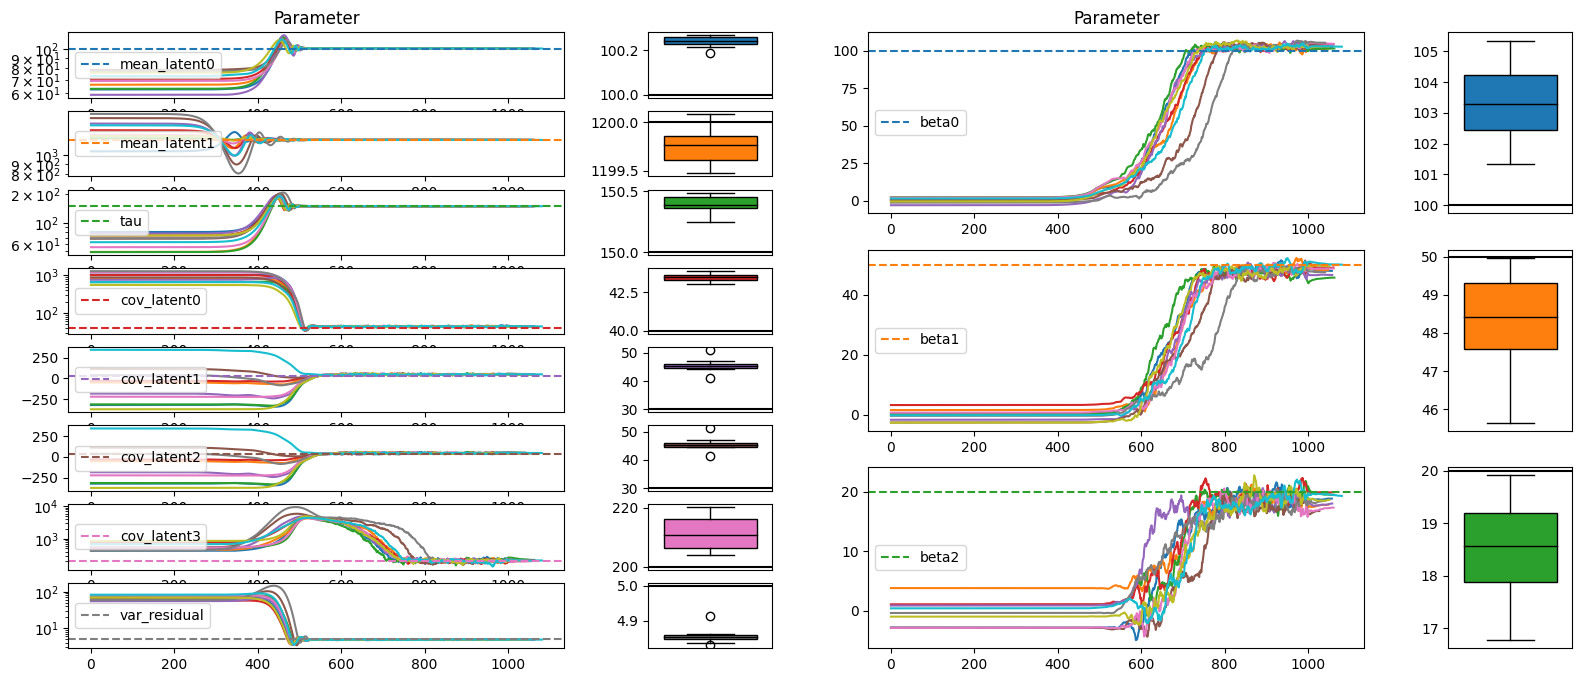

In [ ]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 30], [30, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

#### Correlation forte


Computation time = 0:00:20.633034


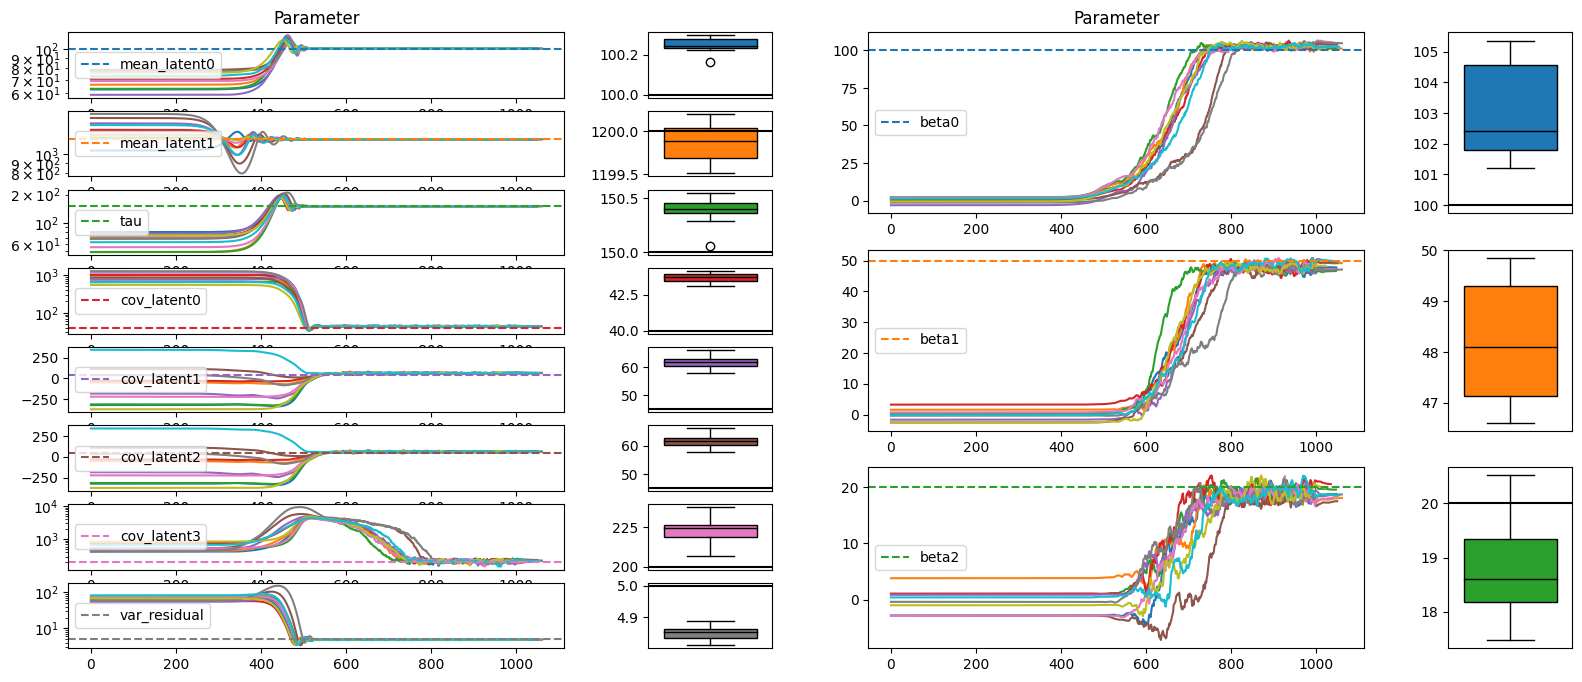

In [ ]:
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.array([[40, 45], [45, 200]]),
    tau=150,
    var_residual=5,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)
myobs, _ = myModel.sample(p_star, jrd.PRNGKey(0))

multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(10)]
)
print(f"\nComputation time = {multi_res.chrono}")

fig = plot_estimation(multi_res, id_to_plot=[0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
sdgplt.get_dataframe_results(
    multi_estim.last_theta, myModel.hstack_params(p_star), myModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

In [ ]:
fig = sdgplt.scatter_estimation(
    multi_estim.last_theta[:, : myModel.DIM_LD].T,
    multi_estim.likelihood[:],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=1,
    ncols=5,
    fig=sdgplt.figure(height=3, width=15),
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.2)

High Dimension

In [ ]:
from sdg4varselect import regularization_path, lasso_into_estim
from sdg4varselect.outputs import RegularizationPathRes, MultiRunRes


def estim_with_flag(model, **kwargs) -> tuple[MultiRunRes, bool]:
    """must return the estimation results and
    a flag which indicates if the regularization path is finished"""
    res_estim = lasso_into_estim(one_estim, model=model, **kwargs)
    dim_ld = model.DIM_LD
    flag = (res_estim[-1].last_theta[dim_ld:] != 0).sum() == 0

    return res_estim, flag


def one_result(prngkey, model, data, lbd_set, save_all=True):

    list_sdg_results, bic = regularization_path(
        estim_fct_with_flag=estim_with_flag,
        prngkey=prngkey,
        lbd_set=lbd_set,
        dim_ld=model.DIM_LD,
        N=model.N * (1 + model.J),
        verbatim=True,  # __name__ == "__main__",
        # additional parameter
        model=model,
        data=data,
        save_all=save_all,
    )

    argmin_bic = bic[-1].argmin()

    return RegularizationPathRes(
        multi_run=list_sdg_results,
        argmin_bic=argmin_bic,
        bic=bic,
        lbd_set=lbd_set,
    )

One function for multiple estimation

In [ ]:
from datetime import datetime

from sdg4varselect.exceptions import sdg4vsNanError
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.miscellaneous import step_message


# ====================================================== #
def multi_run(prngkey, lbd_set, params_star, model, nrun, save_all=True):
    chrono_start = datetime.now()
    print(f'start at {chrono_start.strftime("%d/%m/%Y %H:%M:%S")}')

    prngkey_list = jrd.split(prngkey, num=nrun)

    estim_res = []
    censoring_rate = []
    end = "\r" if __name__ == "__main__" else "\n"
    for k in range(nrun):
        print("run", step_message(k, nrun), end=end)
        data, _ = model.sample(params_star, prngkey_list[k])

        try:
            estim_res.append(
                one_result(
                    prngkey_list[k],
                    model,
                    data=data,
                    lbd_set=lbd_set,
                    save_all=save_all,
                ),
            )

        except sdg4vsNanError as err:
            print(f"{err} :  estimation cancelled !")

    return MultiRunRes(estim_res)

In [ ]:
myHDModel = HDLogisticMixedEffectsModel(N=1000, J=10, P=1000)

p_star_hd = myHDModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([100, 50, 20]), jnp.zeros(shape=(myHDModel.P - 3,))]
    ),
)

lbd_set = 10 ** jnp.linspace(-1.5, -1, num=10)

In [ ]:
# Run thos on a cluster
# res = multi_run(
#     jrd.PRNGKey(10),
#     lbd_set,
#     p_star_hd,
#     myHDModel,
#     nrun=1,
#     save_all=True,
# )

In [ ]:
from sdg4varselect.outputs import TestResults

if "res" in locals():
    results = TestResults(
        [locals()["res"]],
        [{"N": myHDModel.N, "J": myHDModel.J, "P": myHDModel.P}],
    )
else:
    results = TestResults(
        [
            TestResults.load(HDLogisticMEM(1000, 10, 10), filename_add_on=f"S(1, 10)"),
            TestResults.load(HDLogisticMEM(1000, 10, 50), filename_add_on=f"S(22, 30)"),
            TestResults.load(HDLogisticMEM(200, 10, 50), filename_add_on=f"S(1, 10)"),
            TestResults.load(HDLogisticMEM(200, 10, 500), filename_add_on=f"S(1, 10)"),
            TestResults.load(HDLogisticMEM(200, 10, 1000), filename_add_on=f"S(1, 10)"),
        ],
        [
            {"N": 1000, "J": 10, "P": 10},
            {"N": 1000, "J": 10, "P": 50},
            {"N": 200, "J": 10, "P": 50},
            {"N": 200, "J": 10, "P": 500},
            {"N": 200, "J": 10, "P": 1000},
        ],
    )
    nrun_to_keep = min([len(t) for t in results])
    results = TestResults(
        [t.reduce_number_run(nrun_to_keep) for t in results], results.config
    )

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])

import pandas as pd

pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

NameError: name 'HDLogisticMEM' is not defined

In [ ]:
scenarios_labels = [
    f"{n}\n{p}"
    for n, p in zip(
        results.get_scenarios_labels("N"), results.get_scenarios_labels("P")
    )
]
x = results.last_theta[:, :, 1, : myModel.DIM_LD + 4]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    hline=myHDModel.hstack_params(p_star_hd)[: myModel.DIM_LD + 4],
    xlabels=scenarios_labels,
    title=myHDModel.params_names[: myModel.DIM_LD + 4],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

x = jnp.abs((1 - x / myHDModel.hstack_params(p_star_hd)[: myModel.DIM_LD + 4]))
fig = sdgplt.boxplot_estimation(
    x=x.T,
    xlabels=scenarios_labels,
    title=myHDModel.params_names[: myModel.DIM_LD + 4],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("Relative Root Mean Square Error of the MLE", fontsize=15, y=1.05)

In [ ]:
fig = sdgplt.figure(height=4, width=7)
results[-1].sort()

_ = sdgplt.scatter_estimation(
    results[-1].last_theta[:, 1, : myModel.DIM_LD + 5 * 1].T,
    results[-1].likelihood[:, 1],
    vline=myHDModel.hstack_params(p_star)[: myModel.DIM_LD + 5 * 1],
    labels=myHDModel.params_names[: myModel.DIM_LD + 5 * 1],
    nrows=3,
    ncols=5,
    fig=fig,
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.01)

In [ ]:
sdgplt.get_ax(2, 2).plot(results[-1].likelihood)

In [ ]:
last_theta_estim = results[-1].last_theta[:, 1]

sdgplt.get_dataframe_results(
    last_theta_estim, myHDModel.hstack_params(p_star_hd), myHDModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

In [ ]:
fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        sdgplt.plot_reg_path(
            reg_res=results[-1][i * subfigs.shape[0] + j],
            dim_ld=myHDModel.DIM_LD,
            fig=subfig,
        )

In [ ]:
x = results.last_theta[:, :, -1, myHDModel.DIM_LD :]
print(jnp.isnan(x))
print(x.shape)

print(jnp.repeat(x.shape[-2], x.shape[0]))

y = jnp.tile(p_star_hd.beta, reps=30)
print(y.shape)

jnp.tile(p_star_hd.beta, reps=x.shape[:-1] + (1,)).shape

In [ ]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star_hd.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myHDModel.DIM_LD :], p_star_hd.beta
)
print(support_star.shape)


def get_support(x, x_star):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx, x_star) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(
    results.last_theta[:, :, -1, myHDModel.DIM_LD :], p_star_hd.beta
)
print(multi_support.shape)

In [ ]:
jnp.nansum(multi_support, axis=-1)

In [ ]:
lbd_set

In [ ]:
ax = sdgplt.get_ax(4, 4)

ax.hist(jnp.nansum(multi_support, axis=-1))

In [ ]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )